In [4]:
import pandas as pd

# Replace 'your_file.xlsx' with the path to your Excel file
df = pd.read_excel("C:\\Users\\LENOVO\\Downloads\\Afficionado Coffee Roasters.xlsx")

# Display the first 5 rows
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [5]:
#let us start data cleaning
df.shape

(149116, 11)

In [3]:
# Handling the missing values
df.isnull().sum()

transaction_id      0
year                0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [6]:
# Removing the outliers
df.describe()

,transaction_id,year,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116.0,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2025.0,1.438276,5.342063,47.918607,3.382219
std,43153.600016,0.0,0.542509,2.074241,17.930020,2.658723
min,1.000000,2025.0,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2025.0,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2025.0,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2025.0,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2025.0,8.000000,8.000000,87.000000,45.000000


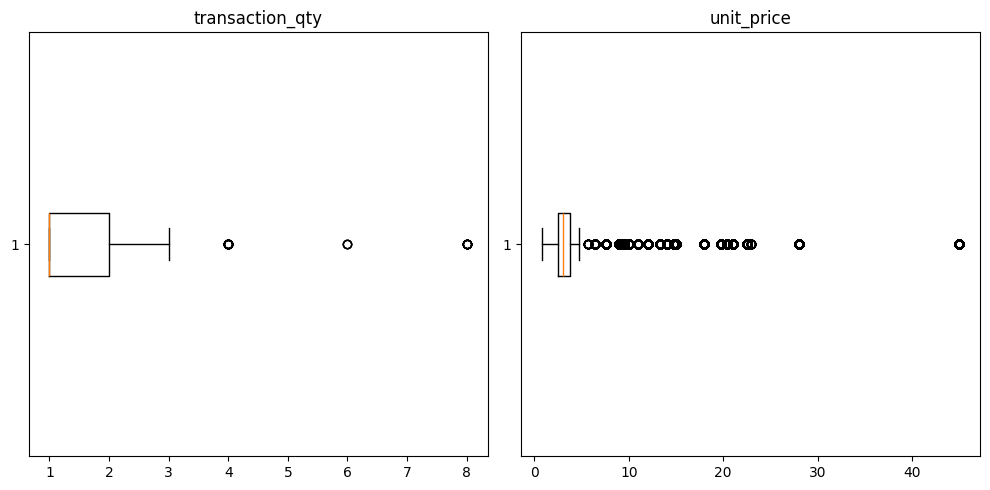

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.boxplot(df['transaction_qty'], vert=False)
plt.title('transaction_qty')

plt.subplot(1, 2, 2)
plt.boxplot(df['unit_price'], vert=False)
plt.title('unit_price')

plt.tight_layout()
plt.show()

In [10]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['unit_price'].quantile(0.25)
Q3 = df['unit_price'].quantile(0.75)

# Interquartile Range
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df_new = df[(df['unit_price'] >= lower_bound) & (df['unit_price'] <= upper_bound)]

# Show cleaned data
df_new.head()


,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


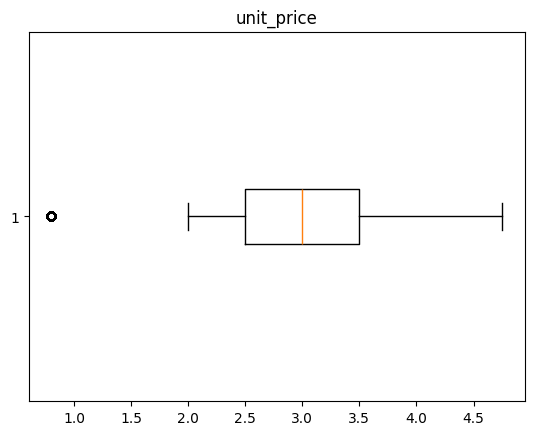

In [11]:
plt.boxplot(df_new['unit_price'], vert=False)
plt.title('unit_price')
plt.show()

In [12]:
# removing the duplicates
df_new = df_new.drop_duplicates()

In [13]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144904 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    144904 non-null  int64  
 1   year              144904 non-null  int64  
 2   transaction_time  144904 non-null  object 
 3   transaction_qty   144904 non-null  int64  
 4   store_id          144904 non-null  int64  
 5   store_location    144904 non-null  object 
 6   product_id        144904 non-null  int64  
 7   unit_price        144904 non-null  float64
 8   product_category  144904 non-null  object 
 9   product_type      144904 non-null  object 
 10  product_detail    144904 non-null  object 
dtypes: float64(1), int64(5), object(5)
memory usage: 13.3+ MB


In [ ]:
from sqlalchemy import create_engine

#connect to postgreSQL
username = "postgres"
password = "12345"
host = "localhost"
port = "5432"
database = "postgres"
engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

#load database into postgreSQL
table_name = "transaction"
df.to_sql(table_name, engine, if_exists="replace", index=False)
print(f"data successfuly loaded into table '{table_name}' in database '{database}'.")


<h2 style="color:blue; font-size:28px;">
Encoding
</h2>

In [14]:
df_new.head(2)

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_new['product_category'] = le.fit_transform(df_new['product_category'])
df_new.head(2)


,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,07:06:11,2,5,Lower Manhattan,32,3.0,1,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,07:08:56,2,5,Lower Manhattan,57,3.1,4,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [27]:
df_new['product_category'].unique()

array([1, 4, 2, 0, 3])

In [26]:
df_new['transaction_qty'].unique()

array([2, 1, 3, 4])

In [54]:
df_new['unit_price'].unique()

array([3.  , 3.1 , 4.5 , 2.  , 4.25, 3.5 , 2.55, 3.75, 2.5 , 4.75, 3.25,
       4.  , 2.2 , 2.45, 0.8 , 4.38, 4.06, 4.69, 2.1 , 2.65])

In [21]:
df_new['Revenue'] = df_new['transaction_qty']*df_new['unit_price']
df_new.head(2)

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue
0,1,2025,07:06:11,2,5,Lower Manhattan,32,3.0,1,Gourmet brewed coffee,Ethiopia Rg,6.0
1,2,2025,07:08:56,2,5,Lower Manhattan,57,3.1,4,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2


In [53]:
D = df_new[['transaction_qty', 'unit_price', 'product_id', 'product_category', 'Revenue']]
print(D)

        transaction_qty  unit_price  product_id  product_category   Revenue
0                     2        3.00    0.153846                 1  0.320988
1                     2        3.10    0.538462                 4  0.333333
2                     2        4.50    0.569231                 2  0.506173
3                     1        2.00    0.000000                 1  0.074074
4                     2        3.10    0.538462                 4  0.333333
...                 ...         ...         ...               ...       ...
149111                2        2.50    0.338462                 4  0.259259
149112                2        3.00    0.415385                 4  0.320988
149113                1        3.00    0.353846                 4  0.135802
149114                1        3.75    0.276923                 1  0.182099
149115                2        0.80    0.646154                 3  0.049383

[144904 rows x 5 columns]


In [55]:
D_new = D.copy()
D_new.head(2)

,transaction_qty,unit_price,product_id,product_category,Revenue
0,2,3.0,0.153846,1,0.320988
1,2,3.1,0.538462,4,0.333333


<h2 style="color:blue; font-size:28px;">
MinMaxScaling
</h2>

In [56]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
D_new[['product_id', 'unit_price', 'Revenue']] = scaler.fit_transform(D_new[['product_id','unit_price', 'Revenue']] )
D_new.head(2)

,transaction_qty,unit_price,product_id,product_category,Revenue
0,2,0.556962,0.153846,1,0.320988
1,2,0.582278,0.538462,4,0.333333


<h2 style="color:blue; font-size:28px;">
Model building and training
</h2>

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

x = D_new[['transaction_qty', 'unit_price', 'product_id', 'product_category']]
y = D_new['Revenue']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(x_train, y_train)

model2 = KNeighborsRegressor()
model2.fit(x_train, y_train)

model3 = DecisionTreeRegressor()
model3.fit(x_train, y_train)

model4 = RandomForestRegressor()
model4.fit(x_train, y_train)

y_pre = model1.predict(x_test)

print("Mean_squared_error:", mean_squared_error(y_test, y_pre))
print("Mean_absolute_error:", mean_absolute_error(y_test, y_pre))
print("R2_score:", r2_score(y_test, y_pre))



Mean_squared_error: 0.0007133770506308725
Mean_absolute_error: 0.01863461993715827
R2_score: 0.9517961240759862


In [60]:
# linear regression model is perfect to predict output
a = float(input("Enter transaction_qty:"))
b = float(input("Enter unit_price:"))
c = float(input("Enter product_id:"))
d = float(input("Enter product_category:"))

revenue_prediction = model1.predict([[a, b, c, d]])
print("Final revenue:", revenue_prediction)

Enter transaction_qty: 6
Enter unit_price: 0.7
Enter product_id: 0.9050
Enter product_category: 1


Final revenue: [1.0865448]


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
